

# GCN for long data

Here I'll make the GCN for the long data I simulated. The ```fake_patient_data.csv``` contains one row for each patient visit, while the ```fake_longitudinal_data.csv``` contains the patient-level outcome $Y_i$. I'm going to go through the process of creating the graph structure, and then the GCN. Each patient's visits will be a single graph $G$, with 

$$
G_i = (X_i, E_i, Y_i)
$$

where:

- $X_i$ contains the node features for the patient's visits,
- $E_i$ contains the directed temporal edges between visits,
- $Y_i$ indicates whether the patient had at least one sick visit.

## Load Packages and Data

In [2]:
import pandas as pd
import torch
import torch.nn as nn

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.nn import global_mean_pool

d:\PyTorch-Practice\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

long_data = pd.read_csv("fake_longitudinal_data.csv")
patient_data = pd.read_csv("fake_patient_data.csv")
patient_data.head()

,subject,n_visits,z,v,n_sick,severity,y
0,1,3,1,-2.141852,1,0.105095,1
1,2,3,3,-0.683650,3,0.335447,1
2,3,6,2,-1.180798,2,0.234909,1
3,4,10,1,1.181002,1,0.765128,1
4,5,10,1,-1.066055,1,0.256154,1


In [4]:
long_data.head()

,subject,visit,sick_visit,gap,time,x1,x2,x3,x4,x5
0,1,1,1,0.000000,0.000000,4.831624,4.496584,3.714200,5.993952,5.703072
1,1,2,0,3.377272,3.377272,5.294986,5.495530,3.938673,4.995435,4.947068
2,1,3,0,0.086067,3.463339,5.050891,4.670009,4.661214,4.792993,5.522478
3,2,1,1,0.000000,0.000000,6.236979,5.231933,5.350978,5.017351,5.747703
4,2,2,1,0.307695,0.307695,6.607205,6.219897,4.269564,5.430589,5.381619


## Defining the Graph
Each patient will be represented by one graph. Within each graph we'll have each node consist of the five features, $x_1, x_2, x_3, x_4, x_5$. The edges between the nodes will need to be the time gaps. We also want to include the resulting response in each graph for later when we train. 

In [6]:
graphs = [] # make the structure
for subject, visits in long_data.groupby("subject"): # subset the long_data into sub-dataframes using the ```for id,subdata in dat.groupby('id'):``` style

    visits = visits.sort_values("time") # sort for generality, lets me copy it later

    # Just going to pass things to tensors for the modeling
    x = torch.tensor(
        visits[["x1", "x2", "x3", "x4", "x5"]].to_numpy(),
        dtype=torch.float32
        )

    times = torch.tensor(
        visits["time"].to_numpy(),
        dtype=torch.float32
    )

    edges = []
    edge_times = []

    for j in range(len(times)):

        
        edges.append([j, j]) # Self-loop
        edge_times.append(
            torch.tensor(0.0) # we make it 0, since we're making our edges delta t
        )

        for k in range(j+1, len(times)): # the j+1 here forces us to only "look forward", otherwise we would be mapping the self loops and backwards.

            edges.append(
                [j,k]
                )
            edge_times.append(
                times[k] - times[j]
            )
            
    # once edges were defined we need to make tensors
    edge_index = torch.tensor(
        edges,
        dtype=torch.long
    ).t().contiguous() # we need to do this because we made a big E x 2 matrix, now we need a 2 x E matrix, so we do .t().contiguous()

    # this is weights, we use a 'torch.stack' to make a special vector type; i dont get why, but it's done.
    edge_times = torch.stack(edge_times)
        
    y = patient_data.loc[ #here we go into the location of the patient_data and find the same subject, then pull that y value
        patient_data["subject"] == subject,
        "y"
    ].iloc[0]

    y = torch.tensor(
        [y],
        dtype=torch.float32
    )

    #finally make our graph structure at the end.
    graph = Data(
        x=x, # these are the features
        edge_index=edge_index, # these are the edges, like node1 -> node2
        edge_times=edge_times, # these are the gaps, so they'll be our weights
        y=y #out sick indicator for training
    )

    graphs.append(graph)


Now we have the graph, let's look at the structure a bit.

As we can see below we have patient 1: comparing the patient info and the graph for that patient we have some easy identifiers.
x=[3,5] corresponds to 3 visits and 5 features. edge_index being [2,6] corresponds to there being 6 edges, 1->2, 1->3, 2->3, and our self-edges. and edge_times corresponds to the 6 weights for those edges.

we want self edges because we want to retain some value from our current node when message passing.


In [7]:
patient_data[patient_data["subject"] == 1], graphs[0], graphs[0].x, graphs[0].edge_index, graphs[0].edge_times

(   subject  n_visits  z         v  n_sick  severity  y
 0        1         3  1 -2.141852       1  0.105095  1,
 Data(x=[3, 5], edge_index=[2, 6], y=[1], edge_times=[6]),
 tensor([[4.8316, 4.4966, 3.7142, 5.9940, 5.7031],
         [5.2950, 5.4955, 3.9387, 4.9954, 4.9471],
         [5.0509, 4.6700, 4.6612, 4.7930, 5.5225]]),
 tensor([[0, 0, 0, 1, 1, 2],
         [0, 1, 2, 1, 2, 2]]),
 tensor([0.0000, 3.3773, 3.4633, 0.0000, 0.0861, 0.0000]))

## Edge-Weight Function

The amount of information passed along an edge will depend on the time difference between the two visits. For an edge $j \rightarrow k,$ let $\Delta t_{jk} = t_k - t_j.$

Next I'll define some functions that converts $\Delta t_{jk}$ into an edge weight $w_{jk}.$ Different weighting assumptions can then be used without changing the graph layer itself. For example:

**No time weighting**: $w_{jk}=1$

**Exponential decay**: $w_{jk}=\exp(-d\Delta t_{jk})$

**Gaussian decay**: $w_{jk}=\exp\left(-\frac{\Delta t_{jk}^2}{d^2}\right)$

where $d$ is some defined constant we choose (we can also train for it). The self-loop has $\Delta t=0$, so both the exponential and Gaussian weighting functions give it weight 1.


In [8]:
def get_edge_weights(edge_times, weighting=None, d = 1.0):

    if weighting == "exponential":
        weights = torch.exp(-d * edge_times)

    elif weighting == "gaussian":
        weights = torch.exp(-(edge_times ** 2) / (d ** 2))

    else:
        print("No weighting was chosen, using edge weights of 1.0\nFor time-based weights use 'exponential', or 'gaussian'.")

        weights = torch.ones_like(edge_times)

    return weights


A little sanity check below to see what it's doing when making the weights. we can see our message when we dont include any information, I want this to remind myself we can change it. keeps the narrative.

In [10]:
get_edge_weights(graphs[0].edge_times)

No weighting was chosen, using edge weights of 1.0
For time-based weights use 'exponential', or 'gaussian'.


tensor([1., 1., 1., 1., 1., 1.])

In [216]:
get_edge_weights(graphs[0].edge_times, weighting='exponential')

tensor([1.0000, 0.0341, 0.0313, 1.0000, 0.9175, 1.0000])

In [217]:
get_edge_weights(graphs[0].edge_times, weighting='gaussian')

tensor([1.0000e+00, 1.1129e-05, 6.1768e-06, 1.0000e+00, 9.9262e-01, 1.0000e+00])

## Creating the layers
### Message Passing
Each node first undergoes a learned linear transformation:

$$
z_j
=
Wh_j+b.
$$

For an edge from node $j$ to node $k$, the message is multiplied by the edge weight:

$$
m_{j\rightarrow k}
=
w_{jk}z_j.
$$

Node $k$ then receives the sum of its incoming weighted messages:

$$
h_k^{(\ell+1)}
=
\sum_{j\in\mathcal{N}(k)}
w_{jk}z_j.
$$

Self-loops are also added.

For a self-loop,

$$
\Delta t_{kk}=0,
$$

so the node's own information receives weight 1 for the exponential and Gaussian weighting functions.

In [ ]:
class GraphLayer(MessagePassing):

    def __init__(self, in_channels, out_channels, weighting=None, d=1.0):

        # we say to sum the node features, but we can add out own weighting
        super().__init__(aggr="add")

        self.linear = nn.Linear(in_channels, out_channels) # this is like a global variable passing to the below functions.
        self.weighting = weighting 
        self.d = d


    def forward(self, x, edge_index, edge_times):
        
        # here we actually make our edge weights from the ds before.
        edge_weight = get_edge_weights( 
            edge_times,
            weighting=self.weighting,
            d=self.d
        )

        # Apply the learned linear transformation to every node
        x = self.linear(x)

        # Send the transformed node features along the edges
        x = self.propagate(
            edge_index=edge_index,
            edge_weight=edge_weight,
            x=x
        )

        return x


    def message(self, x_j, edge_weight):

        # passing the new edges and the weights
        return edge_weight.view(-1, 1) * x_j

## Patient-Level Logistic Output

After the GCN layers, each visit has a learned feature vector.

If patient $i$ has $n_i$ visits, then after the final graph layer we have

$$
H_i \in \mathbb{R}^{n_i \times q},
$$

where $q$ is the number of output features from the graph layer.

Because the outcome $Y_i$ is defined once per patient, the node-level features need to be combined into one patient-level vector.

I will use mean pooling:

$$
g_i
=
\frac{1}{n_i}
\sum_{j=1}^{n_i}
h_{ij}.
$$

This gives one vector $g_i \in \mathbb{R}^{q}$ for each patient.

The patient-level vector is then passed through a linear layer:

$$
\eta_i
=
\beta_0 + \beta^T g_i.
$$

The corresponding probability that the patient experienced a sick day is

$$
P(Y_i=1)
=
\frac{1}{1+\exp(-\eta_i)}.
$$

During training, the model will return the logit $\eta_i$ directly. The sigmoid transformation will be handled by the binary cross-entropy loss.

In [219]:
class LogisticOutput(nn.Module):

    def __init__(self, in_channels):

        super().__init__()

        # dumps out a scalar give some input number of channels
        self.linear = nn.Linear(in_channels, 1)


    def forward(self, x, batch):

        # Collapse all node representations belonging to the same patient into one patient vector
        x = global_mean_pool(x, batch)

        # Convert the patient vector into one logit
        x = self.linear(x)

        return x

## Build the Full GCN Model

The full model will combine the graph message-passing layers with the patient-level logistic output.

The flow is

$$
X
\rightarrow
\text{GCN}_1
\rightarrow
\text{ReLU}
\rightarrow
\text{GCN}_2
\rightarrow
\text{ReLU}
\rightarrow
\text{Pooling}
\rightarrow
\text{Linear Output}.
$$

The first graph layer takes the 5 observed features at each visit and maps them to a 16-dimensional representation.

The second graph layer keeps the representation at 16 dimensions.

Finally, the `LogisticOutput` layer pools the node representations within each patient and produces one logit per patient.

In [220]:
class PatientGCN(nn.Module):

    def __init__(self, weighting=None, d=1.0):

        super().__init__()

        self.gcn1 = GraphLayer(in_channels=5, out_channels=16, weighting=weighting, d=d)
        self.gcn2 = GraphLayer(in_channels=16, out_channels=16, weighting=weighting, d=d)
        self.relu = nn.ReLU()
        self.logistic = LogisticOutput(in_channels=16)

    def forward(self, x, edge_index, edge_times, batch):

        x = self.gcn1(x, edge_index, edge_times)
        x = self.relu(x)
        x = self.gcn2(x, edge_index, edge_times)
        x = self.relu(x)
        x = self.logistic(x, batch)

        return x

Now we have the option to create a model by choosing the weighting we want.

In [221]:
model = PatientGCN()
model

PatientGCN(
  (gcn1): GraphLayer()
  (gcn2): GraphLayer()
  (relu): ReLU()
  (logistic): LogisticOutput(
    (linear): Linear(in_features=16, out_features=1, bias=True)
  )
)

## Choose the Device

PyTorch can run the model on either the CPU or GPU.

If CUDA is available, I will use the GPU. Otherwise, I will use the CPU.

In [222]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

device

device(type='cuda')

## Create the Model on the GPU

Now that CUDA is available, I will create the GCN model and move its trainable parameters to the GPU.

The graph data will also need to be moved to the same device before it is passed through the model.

Recall, we made a model that had no weighting. 
```
model = PatientGCN()
```

In [223]:
model = model.to(device)
model

PatientGCN(
  (gcn1): GraphLayer()
  (gcn2): GraphLayer()
  (relu): ReLU()
  (logistic): LogisticOutput(
    (linear): Linear(in_features=16, out_features=1, bias=True)
  )
)

## split up the data into train test and make batches

Now that the model is defined and ready, we need to get the data finally prepared to train the model. First thing we'll do is split the data into a training and testing split.

In [224]:
from sklearn.model_selection import train_test_split

In [225]:

train_graphs, test_graphs = train_test_split(
    graphs,
    test_size=0.20,
    random_state=123
)

In [226]:
len(train_graphs), len(test_graphs)

(400, 100)

## Create the Train and Test DataLoader

The data are stored as a list of patient graphs.

PyTorch Geometric's `DataLoader` groups several patient graphs into a batch so that multiple patients can be processed during one forward pass.

Each graph remains separate inside the batch, and PyTorch Geometric creates a `batch` vector that keeps track of which nodes belong to which patient.

Here I will use batches of 32 patient graphs.

In [227]:
train_loader = DataLoader(
    train_graphs,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_graphs,
    batch_size=32,
    shuffle=False
)

In [228]:
train_batch = next(iter(train_loader))

train_batch

DataBatch(x=[224, 5], edge_index=[2, 949], y=[32], edge_times=[949], batch=[224], ptr=[33])

In [229]:
test_batch = next(iter(test_loader))

test_batch

DataBatch(x=[215, 5], edge_index=[2, 914], y=[32], edge_times=[914], batch=[215], ptr=[33])

# Time to run the model:

## Move the first Training Batch to the GPU

The model is already stored on the GPU, so the data passed into the model must also be on the GPU.

PyTorch Geometric allows the entire batch object to be moved to the selected device using `.to(device)`.

This moves the node features, edge information, edge times, outcomes, and batch-index vector together.


In [230]:
train_batch

DataBatch(x=[224, 5], edge_index=[2, 949], y=[32], edge_times=[949], batch=[224], ptr=[33])

In [231]:
train_batch = train_batch.to(device)

In [232]:
train_batch.x.device

device(type='cuda', index=0)

In [233]:
train_batch.edge_index.device

device(type='cuda', index=0)

In [234]:
train_batch.edge_times.device

device(type='cuda', index=0)

In [235]:
train_batch.y.device

device(type='cuda', index=0)

## Run One Forward Pass

Now that the model and training batch are both on the GPU, I can pass the batch through the model.

The model will return one logit for each patient graph in the batch.

In [236]:
logits = model(
    train_batch.x,
    train_batch.edge_index,
    train_batch.edge_times,
    train_batch.batch
)

No weighting was chosen, using edge weights of 1.0
For time-based weights use 'exponential', or 'gaussian'.


No weighting was chosen, using edge weights of 1.0
For time-based weights use 'exponential', or 'gaussian'.


In [239]:
logits[:10], logits.shape

(tensor([[0.7645],
         [1.1386],
         [1.0856],
         [0.3179],
         [0.8613],
         [1.5782],
         [0.5396],
         [0.9087],
         [1.0638],
         [0.5973]], device='cuda:0', grad_fn=<SliceBackward0>),
 torch.Size([32, 1]))

## Define the Loss Function

The model returns one raw logit for each patient.

Because the patient outcome is binary,

$$
Y_i \in \{0,1\},
$$

I will use binary cross-entropy loss.

PyTorch's `BCEWithLogitsLoss` combines the sigmoid transformation with binary cross-entropy, so the model should return raw logits rather than probabilities.

In [240]:
loss_function = nn.BCEWithLogitsLoss()

In [244]:
y = train_batch.y.view(-1, 1)

loss = loss_function(
    logits,
    y
)

loss, loss.item()

(tensor(0.6395, device='cuda:0',
        grad_fn=<BinaryCrossEntropyWithLogitsBackward0>),
 0.639506995677948)

## Define the Optimizer

The optimizer updates the trainable parameters in the model using the gradients calculated from the loss.

I will use the Adam optimizer.

The learning rate controls the size of each parameter update.

In [246]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

optimizer, len(optimizer.param_groups[0]["params"])

(Adam (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     decoupled_weight_decay: False
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     lr: 0.01
     maximize: False
     weight_decay: 0
 ),
 6)

## Train the Model

Training will repeat the same sequence over many epochs.

For each batch:

1. Move the batch to the GPU.
2. Clear the old gradients.
3. Run the model forward.
4. Calculate the loss.
5. Use backpropagation to calculate gradients.
6. Update the model parameters.

I will also keep track of the average training loss for each epoch.

In [247]:
n_epochs = 100

training_losses = []

for epoch in range(n_epochs):

    model.train()

    total_loss = 0

    for batch in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        logits = model(
            batch.x,
            batch.edge_index,
            batch.edge_times,
            batch.batch
        )

        y = batch.y.view(-1, 1)

        loss = loss_function(
            logits,
            y
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    training_losses.append(average_loss)

    print(
        f"Epoch {epoch + 1}: "
        f"Loss = {average_loss:.4f}"
    )

No weighting was chosen, using edge weights of 1.0
For time-based weights use 'exponential', or 'gaussian'.
No weighting was chosen, using edge weights of 1.0
For time-based weights use 'exponential', or 'gaussian'.
No weighting was chosen, using edge weights of 1.0
For time-based weights use 'exponential', or 'gaussian'.
No weighting was chosen, using edge weights of 1.0
For time-based weights use 'exponential', or 'gaussian'.
No weighting was chosen, using edge weights of 1.0
For time-based weights use 'exponential', or 'gaussian'.
No weighting was chosen, using edge weights of 1.0
For time-based weights use 'exponential', or 'gaussian'.
No weighting was chosen, using edge weights of 1.0
For time-based weights use 'exponential', or 'gaussian'.
No weighting was chosen, using edge weights of 1.0
For time-based weights use 'exponential', or 'gaussian'.
No weighting was chosen, using edge weights of 1.0
For time-based weights use 'exponential', or 'gaussian'.
No weighting was chosen, usi

In [248]:
training_losses[:10]

[0.8548291371418879,
 0.7329711042917691,
 0.6587322812813979,
 0.650852748980889,
 0.6401259348942683,
 0.6345663024828985,
 0.6352890088008001,
 0.6363414342586811,
 0.623409248315371,
 0.6255400822712824]

## Plot the Training Loss

The training loop stored the average loss from each epoch in `training_losses`.

Plotting this loss over epochs makes it easier to see whether the model is learning and whether the loss has stabilized.

In [249]:
import matplotlib.pyplot as plt

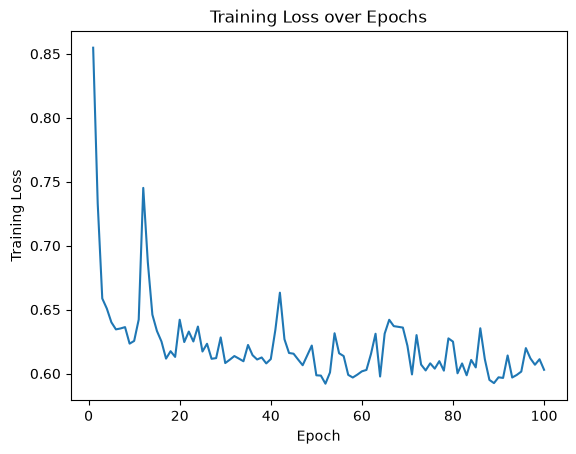

In [250]:
plt.plot(
    range(1, n_epochs + 1),
    training_losses
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss over Epochs")

plt.show()

## Evaluate the Model on the Test Set

After training, the model should be evaluated using patient graphs that were not used to update the model parameters.

During evaluation:

1. Put the model in evaluation mode.
2. Turn off gradient calculation.
3. Move each test batch to the GPU.
4. Run the model forward.
5. Convert the logits to probabilities using the sigmoid function.
6. Convert the probabilities to predicted classes using a cutoff of 0.5.

The true outcomes and predicted probabilities will be stored so that model performance can be examined.

In [251]:
model.eval()

test_probabilities = []
test_predictions = []
test_outcomes = []

with torch.no_grad():

    for batch in test_loader:

        batch = batch.to(device)

        logits = model(
            batch.x,
            batch.edge_index,
            batch.edge_times,
            batch.batch
        )

        probabilities = torch.sigmoid(logits)

        predictions = (
            probabilities >= 0.5
        ).float()

        test_probabilities.extend(
            probabilities.cpu().view(-1).tolist()
        )

        test_predictions.extend(
            predictions.cpu().view(-1).tolist()
        )

        test_outcomes.extend(
            batch.y.cpu().view(-1).tolist()
        )

No weighting was chosen, using edge weights of 1.0
For time-based weights use 'exponential', or 'gaussian'.
No weighting was chosen, using edge weights of 1.0
For time-based weights use 'exponential', or 'gaussian'.
No weighting was chosen, using edge weights of 1.0
For time-based weights use 'exponential', or 'gaussian'.
No weighting was chosen, using edge weights of 1.0
For time-based weights use 'exponential', or 'gaussian'.
No weighting was chosen, using edge weights of 1.0
For time-based weights use 'exponential', or 'gaussian'.
No weighting was chosen, using edge weights of 1.0
For time-based weights use 'exponential', or 'gaussian'.
No weighting was chosen, using edge weights of 1.0
For time-based weights use 'exponential', or 'gaussian'.
No weighting was chosen, using edge weights of 1.0
For time-based weights use 'exponential', or 'gaussian'.


(true y, predicted probability, predicted class)

In [253]:
list(
    zip(
        test_outcomes[:10],
        test_probabilities[:10],
        test_predictions[:10]
    )
)

[(1.0, 0.5854315161705017, 1.0),
 (0.0, 0.5832113027572632, 1.0),
 (1.0, 0.6230178475379944, 1.0),
 (1.0, 0.9680094122886658, 1.0),
 (0.0, 0.4300464987754822, 0.0),
 (1.0, 0.9985381364822388, 1.0),
 (1.0, 0.9983707070350647, 1.0),
 (1.0, 0.6561792492866516, 1.0),
 (1.0, 0.6586554646492004, 1.0),
 (0.0, 0.536826491355896, 1.0)]

In [254]:
correct = 0

for y, prediction in zip(
    test_outcomes,
    test_predictions
):

    if y == prediction:
        correct += 1

test_accuracy = correct / len(test_outcomes)

test_accuracy

0.63

## Evaluate Test Performance

Accuracy alone can be misleading for binary classification, especially if the two outcome classes are not equally common.

I will therefore calculate:

- a confusion matrix,
- sensitivity,
- specificity,
- and the area under the ROC curve (AUC).

The ROC curve evaluates how well the predicted probabilities separate patients with $Y=1$ from patients with $Y=0$ across all possible probability cutoffs.

In [255]:
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [256]:
tn, fp, fn, tp = confusion_matrix(
    test_outcomes,
    test_predictions
).ravel()

tn, fp, fn, tp

(np.int64(3), np.int64(36), np.int64(1), np.int64(60))

In [257]:
sensitivity = tp / (tp + fn)

specificity = tn / (tn + fp)

sensitivity, specificity

(np.float64(0.9836065573770492), np.float64(0.07692307692307693))

In [258]:
auc = roc_auc_score(
    test_outcomes,
    test_probabilities
)

auc

0.7608238755779739

In [259]:
fpr, tpr, thresholds = roc_curve(
    test_outcomes,
    test_probabilities
)

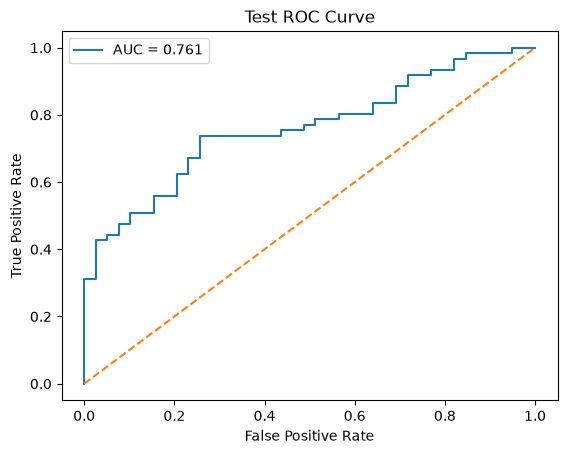

In [260]:
plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test ROC Curve")
plt.legend()

plt.show()

In [261]:
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("AUC:", auc)

Sensitivity: 0.9836065573770492
Specificity: 0.07692307692307693
AUC: 0.7608238755779739
